# Atividade 2 — Funcoes de Ativacao em Redes Neurais

**Disciplina:** Inteligencia Artificial Aplicada  
**Instituicao:** FAETEC — Unidade Resende  
**Professor:** Bruno Menezes  
**Adaptado de:** Bruno Menezes (https://github.com/brunoleomenezes) — uso exclusivamente academico

---

## Objetivo

Demonstrar, na pratica, o papel das **funcoes de ativacao** dentro de um Perceptron.  
Ao final desta atividade, voce sera capaz de responder:

- O que e a **saida bruta** `g(x)` de um neuronio, antes de qualquer ativacao?
- Por que a funcao de ativacao existe e o que ela transforma na saida do neuronio?
- Como **Sigmoid**, **ReLU** e **Tanh** se comportam para os mesmos dados de entrada?
- Em que situacao cada funcao e mais adequada?

---

## Contexto teorico

O **Perceptron** calcula a combinacao linear ponderada das suas entradas:

```
g(x) = w1*x1 + w2*x2 + ... + wn*xn + b
```

Esse valor `g(x)` e a **saida bruta** — ele nao tem limite de escala e nao oferece  
interpretacao probabilistica direta. A **funcao de ativacao** `f` transforma essa saida:

```
y_pred = f( g(x) )
```

A funcao de ativacao introduz **nao-linearidade** na rede. Sem ela, qualquer numero  
de camadas empilhadas seria matematicamente equivalente a uma unica camada linear,  
incapaz de aprender padroes complexos.

---

## Estrutura desta atividade

| Secao | Conteudo |
|-------|----------|
| 1 | Importacao das bibliotecas |
| 2 | Geracao e visualizacao do dataset |
| 3 | Construcao do Perceptron com pesos definidos manualmente |
| 4 | Visualizacao da fronteira de decisao |
| 5.1 | Funcao de ativacao Sigmoid |
| 5.2 | Funcao de ativacao ReLU |
| 5.3 | Funcao de ativacao Tanh |
| 6 | Comparacao visual das tres curvas |
| 7 | Tabela consolidada e analise |
| 8 | Exercicio: escolha justificada |

---
## Secao 1 — Importacao das Bibliotecas

In [1]:
# ------------------------------------------------------------
# Importacao das bibliotecas utilizadas nesta atividade.
#
# torch              : framework PyTorch para construcao de redes neurais
# torch.nn           : modulo com camadas prontas e funcoes de ativacao
# sklearn.datasets   : geracao de datasets sinteticos para experimentos
# numpy              : operacoes numericas e manipulacao de arrays
# matplotlib.pyplot  : visualizacao grafica dos dados e resultados
# ------------------------------------------------------------

import torch
from torch import nn

from sklearn.datasets import make_classification

import numpy as np
import matplotlib.pyplot as plt

# Configuracao global dos graficos
plt.rcParams['figure.dpi']        = 100
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Bibliotecas carregadas com sucesso.')
print(f'Versao do PyTorch: {torch.__version__}')

Bibliotecas carregadas com sucesso.
Versao do PyTorch: 2.10.0+cpu


---
## Secao 2 — Geracao e Visualizacao do Dataset

Criamos um dataset sintetico bidimensional com **duas classes** (rotulos 0 e 1).  
Cada amostra possui duas caracteristicas — `x1` e `x2` — que correspondem  
aos dois eixos do grafico.

Este e exatamente o tipo de problema que o Perceptron foi projetado para resolver:  
encontrar uma **reta** (fronteira de decisao linear) que separe as duas classes.

**Parametros relevantes de `make_classification`:**

| Parametro | Valor | Significado |
|-----------|-------|-------------|
| `n_samples` | 100 | Total de amostras geradas |
| `n_features` | 2 | Duas variaveis de entrada (x1 e x2) |
| `n_redundant` | 0 | Sem features redundantes |
| `n_informative` | 1 | Uma feature carrega o padrao principal |
| `n_clusters_per_class` | 1 | Cada classe forma um unico agrupamento |
| `random_state` | 46 | Semente para reproducibilidade |

In [2]:
# ------------------------------------------------------------
# Geracao do dataset de classificacao binaria.
#
# X : matriz de entradas com shape (100, 2)
#     Cada linha e uma amostra; as colunas sao as features x1 e x2.
# Y : vetor de rotulos com shape (100,)
#     Cada elemento e 0 (classe negativa) ou 1 (classe positiva).
#
# random_state=46 garante que o mesmo dataset sera gerado a cada
# execucao, mantendo os resultados reproduziveis.
# ------------------------------------------------------------

np.random.seed(46)

X, Y = make_classification(
    n_samples            = 100,
    n_features           = 2,
    n_redundant          = 0,
    n_informative        = 1,
    n_clusters_per_class = 1,
    random_state         = 46
)

print('Descricao do dataset:')
print(f'  X — shape : {X.shape}   ({X.shape[0]} amostras, {X.shape[1]} features)')
print(f'  Y — shape : {Y.shape}   ({Y.shape[0]} rotulos)')
print(f'  Classes   : {np.unique(Y)}   (0 = negativo | 1 = positivo)')
print(f'  Por classe: Classe 0 = {(Y==0).sum()} amostras | Classe 1 = {(Y==1).sum()} amostras')

Descricao do dataset:
  X — shape : (100, 2)   (100 amostras, 2 features)
  Y — shape : (100,)   (100 rotulos)
  Classes   : [0 1]   (0 = negativo | 1 = positivo)
  Por classe: Classe 0 = 50 amostras | Classe 1 = 50 amostras


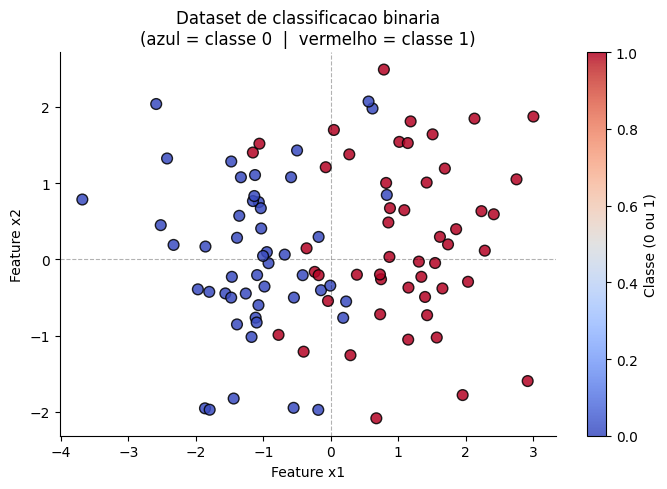

In [3]:
# ------------------------------------------------------------
# Visualizacao dos dados no plano x1 x x2.
#
# Cada ponto representa uma amostra. A cor indica a classe:
# azul = classe 0 | vermelho = classe 1.
#
# Observe se os dois grupos sao visivelmente separaveis
# por uma reta — essa e a premissa do Perceptron.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    X[:, 0], X[:, 1],
    c         = Y,
    cmap      = 'coolwarm',
    edgecolor = 'k',
    s         = 60,
    alpha     = 0.85
)

# Eixos de referencia
ax.axvline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.30)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.30)

ax.set_xlabel('Feature x1')
ax.set_ylabel('Feature x2')
ax.set_title('Dataset de classificacao binaria\n(azul = classe 0  |  vermelho = classe 1)')

plt.colorbar(sc, ax=ax, label='Classe (0 ou 1)')
plt.tight_layout()
plt.show()

---
## Secao 3 — Construcao do Perceptron com Pesos Manuais

### Por que definir os pesos manualmente?

Em producao, os pesos de uma rede neural sao **aprendidos automaticamente** pelo  
algoritmo de Backpropagation durante o treinamento. Aqui, os definimos manualmente  
com dois objetivos pedagogicos:

1. Tornar explicita a equivalencia entre o Perceptron e a **equacao da reta**
2. Controlar a posicao da fronteira de decisao para analisar seus efeitos ponto a ponto

### A fronteira de decisao como equacao de reta

A fronteira de decisao e o conjunto de pontos onde `g(x) = 0`:

```
w1*x1 + w2*x2 + b = 0
```

Isolando `x2` para exibir no grafico:

```
x2 = (-w1 * x1 - b) / w2
```

Os pesos `w1`, `w2` e o bias `b` determinam a **inclinacao** e o **deslocamento** dessa reta.

### Pesos utilizados nesta atividade

| Parametro | Valor | Papel geometrico |
|-----------|-------|------------------|
| `w1` | 5.0 | Controla a inclinacao da fronteira em relacao ao eixo x1 |
| `w2` | 1.0 | Escala a contribuicao do eixo x2 |
| `b`  | -0.4 | Desloca a posicao horizontal da fronteira |

In [4]:
# ------------------------------------------------------------
# Definicao manual dos coeficientes da fronteira de decisao.
#
# Estes valores foram escolhidos para gerar uma separacao
# visualmente adequada para este dataset especifico.
# Em um treinamento real, seriam ajustados automaticamente.
# ------------------------------------------------------------

w1 = 5.0    # peso da feature x1
w2 = 1.0    # peso da feature x2
b  = -0.4   # bias (deslocamento da reta)

# Verificacao analitica para o ponto de teste p = (-1, 1):
#
#   g(p) = w1*(-1) + w2*(1) + b
#        = 5*(-1)  + 1*(1)  + (-0.4)
#        = -5 + 1 - 0.4
#        = -4.4
#
# g(p) < 0 => ponto abaixo da fronteira => predicao: classe 0

p_teste = (-1.0, 1.0)
g_p     = w1 * p_teste[0] + w2 * p_teste[1] + b

print(f'Pesos configurados: w1={w1} | w2={w2} | b={b}')
print()
print(f'Verificacao para o ponto p = {p_teste}:')
print(f'  g(p) = {w1}*({p_teste[0]}) + {w2}*({p_teste[1]}) + ({b}) = {g_p:.1f}')
print(f'  g(p) = {g_p:.1f} < 0  =>  ponto na regiao da classe 0')

Pesos configurados: w1=5.0 | w2=1.0 | b=-0.4

Verificacao para o ponto p = (-1.0, 1.0):
  g(p) = 5.0*(-1.0) + 1.0*(1.0) + (-0.4) = -4.4
  g(p) = -4.4 < 0  =>  ponto na regiao da classe 0


In [5]:
# ------------------------------------------------------------
# Construcao do Perceptron usando PyTorch.
#
# nn.Linear(in_features=2, out_features=1) cria uma camada
# que calcula exatamente:
#
#   g(x) = w1*x1 + w2*x2 + b
#
# Por padrao, o PyTorch inicializa os pesos com valores aleatorios
# (inicializacao de Kaiming). Substituimos esses pesos pelos
# valores manuais definidos acima usando nn.Parameter(),
# que registra o tensor como parametro treinavel do modelo.
# ------------------------------------------------------------

perceptron = nn.Linear(in_features=2, out_features=1)

print('Pesos iniciais (aleatorios, gerados pelo PyTorch):')
print(f'  weight : {perceptron.weight.data}')
print(f'  bias   : {perceptron.bias.data}')

# Substituicao pelos pesos manuais.
# torch.Tensor([[w1, w2]]) tem shape (1, 2):
# 1 neuronio de saida, 2 entradas (x1 e x2).
perceptron.weight = nn.Parameter(torch.Tensor([[w1, w2]]))
perceptron.bias   = nn.Parameter(torch.Tensor([b]))

print()
print('Pesos apos substituicao manual:')
print(f'  weight : {perceptron.weight.data}   =>  [w1={w1}, w2={w2}]')
print(f'  bias   : {perceptron.bias.data}     =>  b={b}')

Pesos iniciais (aleatorios, gerados pelo PyTorch):
  weight : tensor([[-0.4612, -0.2263]])
  bias   : tensor([0.2139])

Pesos apos substituicao manual:
  weight : tensor([[5., 1.]])   =>  [w1=5.0, w2=1.0]
  bias   : tensor([-0.4000])     =>  b=-0.4


---
## Secao 4 — Visualizacao da Fronteira de Decisao

A funcao auxiliar `plot_fronteira` plota o dataset e a reta de separacao.  
Ela sera reutilizada em todas as secoes de comparacao das funcoes de ativacao.

Quatro pontos especificos do dataset (indices 17, 21, 43 e 66) sao destacados  
para analise detalhada nas secoes seguintes. Eles foram escolhidos para representar  
situacoes distintas: pontos proximos e distantes da fronteira, de ambas as classes.

In [6]:
# ------------------------------------------------------------
# Funcao auxiliar: plot_fronteira
#
# Plota o dataset colorido por classe e a reta de separacao
# definida por: w1*x1 + w2*x2 + b = 0
#
# Parametros:
#   w1, w2, b : coeficientes da fronteira de decisao
#   ax        : eixo matplotlib; se None, usa o eixo ativo
# ------------------------------------------------------------

def plot_fronteira(w1, w2, b, ax=None):
    """
    Plota o dataset de classificacao e a fronteira de decisao linear
    definida por w1*x1 + w2*x2 + b = 0.

    A fronteira e calculada isolando x2:
        x2 = (-w1*x1 - b) / w2
    """
    if ax is None:
        ax = plt.gca()

    # Plota os pontos coloridos por classe (azul=0, vermelho=1)
    ax.scatter(
        X[:, 0], X[:, 1],
        c=Y, cmap='coolwarm', edgecolor='k',
        s=40, alpha=0.70, zorder=2
    )

    # Registra os limites atuais do grafico para preserva-los apos plotar a reta
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # Calcula a reta da fronteira: x2 = (-w1*x1 - b) / w2
    x1_vals = np.linspace(xmin - 0.5, xmax + 0.5, 300)
    x2_vals = (-w1 * x1_vals - b) / w2

    ax.plot(x1_vals, x2_vals, color='navy', linewidth=1.8,
            label='Fronteira: g(x)=0', zorder=3)

    # Linhas de referencia dos eixos coordenados
    ax.axvline(0, color='k', linewidth=0.6, linestyle='--', alpha=0.30)
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--', alpha=0.30)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('Feature x1')
    ax.set_ylabel('Feature x2')


# Constantes compartilhadas por todas as secoes de analise
INDICES_ANALISE = [17, 21, 43, 66]       # indices dos quatro pontos selecionados
MARCADORES      = ['^', 'v', '>', '<']   # marcador distinto para cada ponto
CORES_DESTAQUE  = ['red', 'limegreen', 'blue', 'dimgray']

print('Funcao plot_fronteira definida.')
print(f'Pontos selecionados para analise: {INDICES_ANALISE}')

Funcao plot_fronteira definida.
Pontos selecionados para analise: [17, 21, 43, 66]


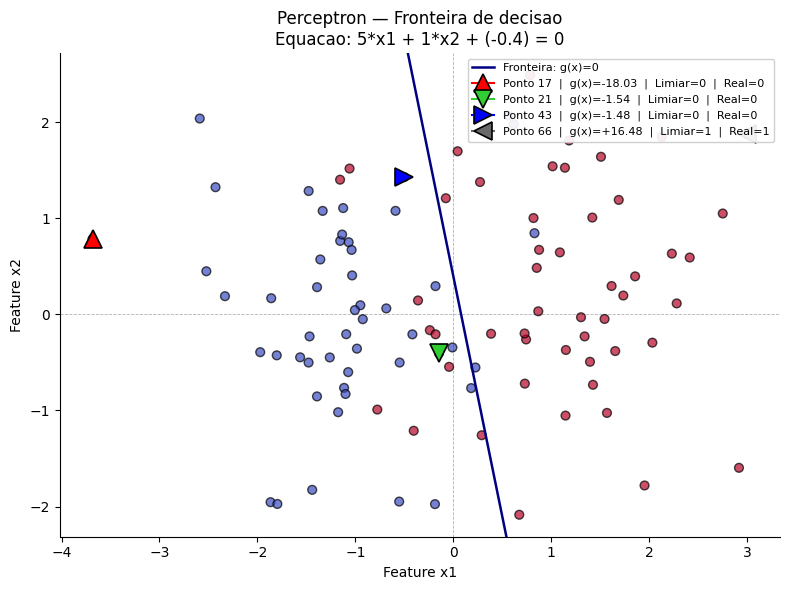

Resumo dos pontos selecionados:
   Indice |      x1 |      x2 |     g(x) |  Limiar |  Real
  -------------------------------------------------------
       17 |  -3.684 |   0.785 |  -18.033 |       0 |     0
       21 |  -0.146 |  -0.405 |   -1.536 |       0 |     0
       43 |  -0.501 |   1.428 |   -1.476 |       0 |     0
       66 |   3.002 |   1.873 |  +16.483 |       1 |     1


In [7]:
# ------------------------------------------------------------
# Visualizacao inicial: fronteira de decisao com os quatro
# pontos de analise destacados.
#
# Para cada ponto exibimos na legenda:
#   g(x)      — saida bruta da combinacao linear
#   Limiar    — predicao por limiar zero (g>=0 => classe 1)
#   Real      — rotulo verdadeiro do dataset
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))
plot_fronteira(w1, w2, b, ax=ax)

for k, idx in enumerate(INDICES_ANALISE):

    # Converte o ponto numpy para tensor PyTorch para passar pelo perceptron
    x_tensor = torch.Tensor(X[idx])

    # Calcula a saida bruta g(x) = w1*x1 + w2*x2 + b
    # .item() converte o tensor escalar em float Python
    g_x = perceptron(x_tensor).item()

    # Classificacao por limiar: g(x) >= 0 => classe 1, caso contrario => classe 0
    pred_limiar = 1 if g_x >= 0 else 0

    legenda = (f'Ponto {idx:02d}  |  g(x)={g_x:+.2f}  |  '
               f'Limiar={pred_limiar}  |  Real={Y[idx]}')

    ax.plot(X[idx, 0], X[idx, 1],
            marker=MARCADORES[k], color=CORES_DESTAQUE[k],
            markersize=13, markeredgecolor='k', markeredgewidth=1.2,
            label=legenda, zorder=5)

ax.set_title(f'Perceptron — Fronteira de decisao\n'
             f'Equacao: {w1:.0f}*x1 + {w2:.0f}*x2 + ({b}) = 0')
ax.legend(loc='upper right', fontsize=8, framealpha=0.92)
plt.tight_layout()
plt.show()

# Resumo textual dos quatro pontos
print('Resumo dos pontos selecionados:')
print(f'  {"Indice":>7} | {"x1":>7} | {"x2":>7} | {"g(x)":>8} | {"Limiar":>7} | {"Real":>5}')
print('  ' + '-' * 55)
for idx in INDICES_ANALISE:
    x_t  = torch.Tensor(X[idx])
    g_x  = perceptron(x_t).item()
    pred = 1 if g_x >= 0 else 0
    print(f'  {idx:>7} | {X[idx,0]:>7.3f} | {X[idx,1]:>7.3f} | '
          f'{g_x:>+8.3f} | {pred:>7} | {Y[idx]:>5}')

---
## Secao 5 — Comparacao das Funcoes de Ativacao

Aplicamos, em sequencia, as tres funcoes de ativacao sobre os mesmos quatro pontos.  
O objetivo e observar como cada funcao transforma a mesma saida bruta `g(x)`.

Em cada subsecao o notebook calcula e exibe tres colunas:

| Coluna | Descricao |
|--------|----------|
| `g(x)` | Saida bruta da combinacao linear — sem limite de escala |
| `Limiar` | Regra binaria simples: `g(x) >= 0` → classe 1, caso contrario → classe 0 |
| `f(g(x))` | Saida apos a funcao de ativacao escolhida |

### Resumo das tres funcoes

| Funcao | Formula | Intervalo de saida | Uso tipico |
|--------|---------|-------------------|------------|
| **Sigmoid** | `1 / (1 + e^(-x))` | `(0, 1)` | Camada de saida — classificacao binaria |
| **ReLU** | `max(0, x)` | `[0, +inf)` | Camadas ocultas — padrao em Deep Learning |
| **Tanh** | `(e^x - e^(-x)) / (e^x + e^(-x))` | `(-1, +1)` | RNNs e tarefas onde o sinal negativo importa |

In [8]:
# ------------------------------------------------------------
# Funcao auxiliar: analisar_ativacao
#
# Para uma funcao de ativacao fornecida, plota os quatro pontos
# de analise com g(x), predicao por limiar e saida ativada
# na legenda do grafico. Retorna os resultados numericos.
#
# Parametros:
#   activation  : instancia de nn.Module  (ex: nn.Sigmoid())
#   nome_funcao : string com o nome da funcao, para titulos e legendas
#   ax          : eixo matplotlib; se None, cria figura nova
#
# Retorno:
#   lista de dicionarios com idx, x1, x2, g_x, limiar, ativada, real
# ------------------------------------------------------------

def analisar_ativacao(activation, nome_funcao, ax=None):
    """
    Plota os quatro pontos de analise com tres metricas na legenda:
      g(x)          — saida bruta do perceptron (combinacao linear)
      pred_limiar   — classificacao por limiar zero
      saida_ativada — g(x) apos a funcao de ativacao
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    plot_fronteira(w1, w2, b, ax=ax)

    resultados = []

    for k, idx in enumerate(INDICES_ANALISE):

        x_tensor = torch.Tensor(X[idx])

        # Passo 1 — saida bruta: combinacao linear g(x)
        g_x_tensor = perceptron(x_tensor)
        g_x_valor  = g_x_tensor.item()

        # Passo 2 — classificacao por limiar zero
        pred_limiar = 1 if g_x_valor >= 0 else 0

        # Passo 3 — aplicacao da funcao de ativacao sobre g(x)
        # A funcao recebe o tensor de g(x) e retorna o tensor transformado
        saida_ativada = activation(g_x_tensor).item()

        resultados.append({
            'idx'    : idx,
            'x1'     : X[idx, 0],
            'x2'     : X[idx, 1],
            'g_x'    : g_x_valor,
            'limiar' : pred_limiar,
            'ativada': saida_ativada,
            'real'   : Y[idx]
        })

        legenda = (f'Ponto {idx:02d}  |  g(x)={g_x_valor:+.2f}  |  '
                   f'Limiar={pred_limiar}  |  {nome_funcao}={saida_ativada:+.3f}')

        ax.plot(X[idx, 0], X[idx, 1],
                marker=MARCADORES[k], color=CORES_DESTAQUE[k],
                markersize=13, markeredgecolor='k', markeredgewidth=1.2,
                label=legenda, zorder=5)

    ax.set_title(f'Funcao de ativacao: {nome_funcao}',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, framealpha=0.95)

    return resultados


print('Funcao analisar_ativacao definida.')

Funcao analisar_ativacao definida.


---
### 5.1 — Sigmoid

**Formula:** `sigma(x) = 1 / (1 + e^(-x))`

**Comportamento:**

| Valor de `g(x)` | Saida da Sigmoid | Interpretacao |
|-----------------|-----------------|---------------|
| Muito negativo | Proxima de 0 | Alta confianca na classe 0 |
| Zero | Exatamente 0.5 | Incerteza maxima |
| Muito positivo | Proxima de 1 | Alta confianca na classe 1 |

**Por que e usada na camada de saida de classificadores binarios?**  
Porque sua saida em `(0, 1)` pode ser interpretada diretamente como  
a **probabilidade estimada** de o ponto pertencer a classe 1.

**Limitacao — Vanishing Gradient:**  
Para valores de `|g(x)|` muito grandes, a curva fica praticamente plana  
e o gradiente fica proximo de zero, dificultando o treinamento em redes profundas.

Comportamento da Sigmoid para valores de referencia:
    g(x)  =>   Sigmoid(g(x))  |  Interpretacao
  ----------------------------------------------------------
    -5.0  =>          0.0067  |  alta confianca — classe 0
    -2.0  =>          0.1192  |  alta confianca — classe 0
    -1.0  =>          0.2689  |  regiao de incerteza
    +0.0  =>          0.5000  |  regiao de incerteza
    +1.0  =>          0.7311  |  regiao de incerteza
    +2.0  =>          0.8808  |  alta confianca — classe 1
    +5.0  =>          0.9933  |  alta confianca — classe 1



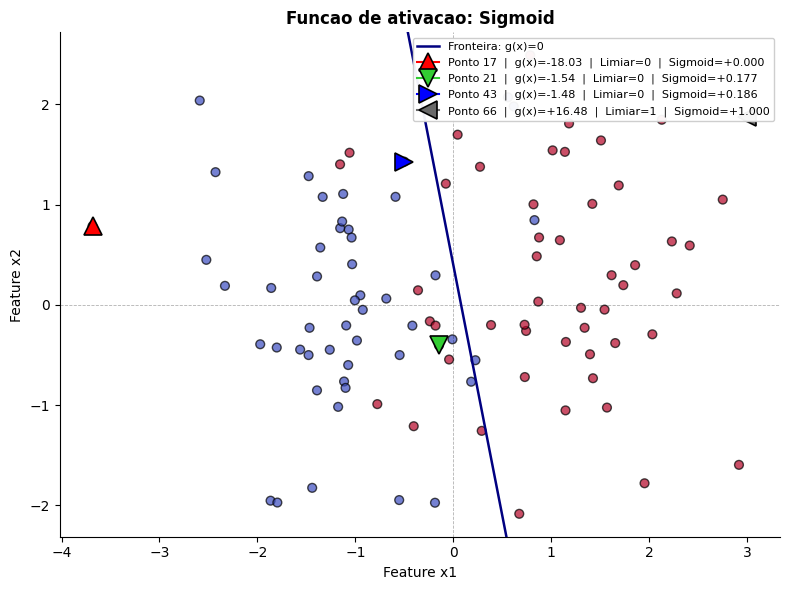

Resultados nos quatro pontos de analise — Sigmoid:
   Ponto |     g(x) |  Limiar |   Sigmoid |  Real
  --------------------------------------------------
      17 |  -18.033 |       0 |    0.0000 |     0
      21 |   -1.536 |       0 |    0.1772 |     0
      43 |   -1.476 |       0 |    0.1860 |     0
      66 |  +16.483 |       1 |    1.0000 |     1


In [9]:
# ------------------------------------------------------------
# Sigmoid — nn.Sigmoid()
#
# Demonstracao para valores de referencia e visualizacao
# sobre os quatro pontos de analise.
# ------------------------------------------------------------

activation_sigmoid = nn.Sigmoid()

print('Comportamento da Sigmoid para valores de referencia:')
print(f'  {"g(x)":>6}  =>  {"Sigmoid(g(x))":>14}  |  Interpretacao')
print('  ' + '-' * 58)
for v in [-5.0, -2.0, -1.0, 0.0, 1.0, 2.0, 5.0]:
    saida = activation_sigmoid(torch.tensor(v)).item()
    if saida > 0.8:
        interp = 'alta confianca — classe 1'
    elif saida < 0.2:
        interp = 'alta confianca — classe 0'
    else:
        interp = 'regiao de incerteza'
    print(f'  {v:>+6.1f}  =>  {saida:>14.4f}  |  {interp}')

print()

fig, ax = plt.subplots(figsize=(8, 6))
res_sigmoid = analisar_ativacao(activation_sigmoid, 'Sigmoid', ax=ax)
plt.tight_layout()
plt.show()

print('Resultados nos quatro pontos de analise — Sigmoid:')
print(f'  {"Ponto":>6} | {"g(x)":>8} | {"Limiar":>7} | {"Sigmoid":>9} | {"Real":>5}')
print('  ' + '-' * 50)
for r in res_sigmoid:
    print(f'  {r["idx"]:>6} | {r["g_x"]:>+8.3f} | {r["limiar"]:>7} | '
          f'{r["ativada"]:>9.4f} | {r["real"]:>5}')

---
### 5.2 — ReLU (Rectified Linear Unit)

**Formula:** `ReLU(x) = max(0, x)`

**Comportamento:**

| Valor de `g(x)` | Saida da ReLU | Interpretacao |
|-----------------|--------------|---------------|
| Negativo ou zero | `0.0` | Neuronio silencioso — nao propaga sinal |
| Positivo | `g(x)` inalterado | Neuronio ativo — passa o valor original |

**Por que e o padrao atual em camadas ocultas de Deep Learning?**

1. **Eficiencia computacional:** `max(0, x)` e uma das operacoes mais rapidas
2. **Gradiente constante:** para valores positivos, o gradiente e 1 — sem vanishing gradient
3. **Esparsidade:** parte dos neuronios fica silenciosa, tornando a rede mais eficiente

**Limitacao — Dying ReLU:**  
Um neuronio que recebe consistentemente valores negativos produz sempre saida zero  
e para de aprender permanentemente. Variantes como **Leaky ReLU** mitigam esse problema.

**Atencao:** por nao ter limite superior, a saida da ReLU nao e interpretavel  
como probabilidade. Por isso, ela e usada em **camadas ocultas**, nao na saida final.

Comportamento da ReLU para valores de referencia:
    g(x)  =>    ReLU(g(x))  |  Status do neuronio
  --------------------------------------------------------
    -5.0  =>        0.0000  |  SILENCIOSO — nao propaga
    -2.0  =>        0.0000  |  SILENCIOSO — nao propaga
    -1.0  =>        0.0000  |  SILENCIOSO — nao propaga
    +0.0  =>        0.0000  |  SILENCIOSO — nao propaga
    +1.0  =>        1.0000  |  ATIVO — valor propagado
    +2.0  =>        2.0000  |  ATIVO — valor propagado
    +5.0  =>        5.0000  |  ATIVO — valor propagado



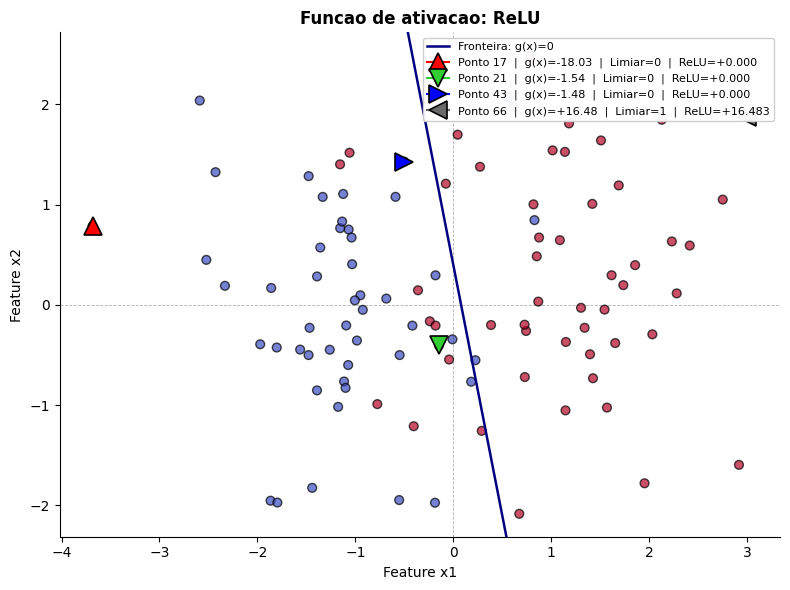

Resultados nos quatro pontos de analise — ReLU:
   Ponto |     g(x) |  Limiar |      ReLU |  Real
  --------------------------------------------------
      17 |  -18.033 |       0 |    0.0000 |     0
      21 |   -1.536 |       0 |    0.0000 |     0
      43 |   -1.476 |       0 |    0.0000 |     0
      66 |  +16.483 |       1 |   16.4828 |     1


In [10]:
# ------------------------------------------------------------
# ReLU — nn.ReLU()
#
# Para g(x) <= 0: ReLU retorna 0.0  (neuronio silencioso)
# Para g(x) >  0: ReLU retorna g(x) (neuronio ativo)
# ------------------------------------------------------------

activation_relu = nn.ReLU()

print('Comportamento da ReLU para valores de referencia:')
print(f'  {"g(x)":>6}  =>  {"ReLU(g(x))":>12}  |  Status do neuronio')
print('  ' + '-' * 56)
for v in [-5.0, -2.0, -1.0, 0.0, 1.0, 2.0, 5.0]:
    saida  = activation_relu(torch.tensor(v)).item()
    status = 'SILENCIOSO — nao propaga' if saida == 0.0 else 'ATIVO — valor propagado'
    print(f'  {v:>+6.1f}  =>  {saida:>12.4f}  |  {status}')

print()

fig, ax = plt.subplots(figsize=(8, 6))
res_relu = analisar_ativacao(activation_relu, 'ReLU', ax=ax)
plt.tight_layout()
plt.show()

print('Resultados nos quatro pontos de analise — ReLU:')
print(f'  {"Ponto":>6} | {"g(x)":>8} | {"Limiar":>7} | {"ReLU":>9} | {"Real":>5}')
print('  ' + '-' * 50)
for r in res_relu:
    print(f'  {r["idx"]:>6} | {r["g_x"]:>+8.3f} | {r["limiar"]:>7} | '
          f'{r["ativada"]:>9.4f} | {r["real"]:>5}')

---
### 5.3 — Tanh (Tangente Hiperbolica)

**Formula:** `tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))`

**Comportamento:**

| Valor de `g(x)` | Saida da Tanh | Interpretacao |
|-----------------|--------------|---------------|
| Muito negativo | Proxima de -1 | Fortemente negativo |
| Zero | Exatamente 0 | Saida centralizada em zero |
| Muito positivo | Proxima de +1 | Fortemente positivo |

**Vantagem sobre a Sigmoid:**  
A Tanh e **centralizada em zero** — sua media de saida e zero, nao 0.5.  
Isso produz gradientes mais simetricos e acelera a convergencia do treinamento.

**Vantagem sobre a ReLU:**  
Produz valores **negativos**, que preservam a direcao do erro para o Backpropagation.  
A ReLU suprime completamente os valores negativos, descartando essa informacao.

**Limitacao:**  
Como a Sigmoid, sofre de vanishing gradient nas regioes de saturacao.

**Uso tipico:**  
Redes neurais recorrentes (RNNs, LSTMs) e camadas onde o sinal  
negativo carrega informacao relevante para a tarefa.

Comportamento da Tanh para valores de referencia:
    g(x)  =>    Tanh(g(x))  |  Caracteristica
  ------------------------------------------------------------
    -5.0  =>       -0.9999  |  negativo forte — regiao de saturacao
    -2.0  =>       -0.9640  |  negativo forte — regiao de saturacao
    -1.0  =>       -0.7616  |  regiao central — gradiente significativo
    +0.0  =>       +0.0000  |  regiao central — gradiente significativo
    +1.0  =>       +0.7616  |  regiao central — gradiente significativo
    +2.0  =>       +0.9640  |  positivo forte — regiao de saturacao
    +5.0  =>       +0.9999  |  positivo forte — regiao de saturacao



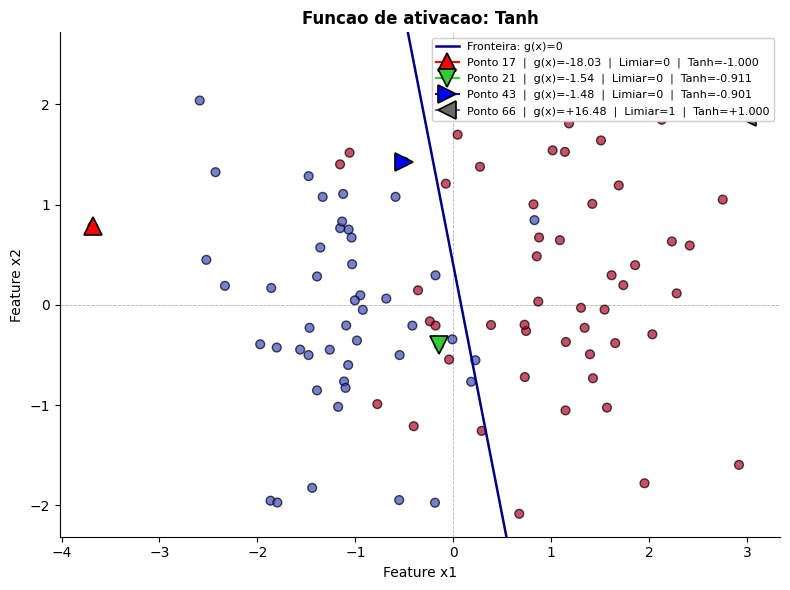

Resultados nos quatro pontos de analise — Tanh:
   Ponto |     g(x) |  Limiar |      Tanh |  Real
  --------------------------------------------------
      17 |  -18.033 |       0 |   -1.0000 |     0
      21 |   -1.536 |       0 |   -0.9114 |     0
      43 |   -1.476 |       0 |   -0.9008 |     0
      66 |  +16.483 |       1 |   +1.0000 |     1


In [11]:
# ------------------------------------------------------------
# Tanh — nn.Tanh()
#
# Para g(x) muito negativo : Tanh aprox. -1  (negativo forte)
# Para g(x) = 0            : Tanh = 0.0      (centralizado)
# Para g(x) muito positivo : Tanh aprox. +1  (positivo forte)
# ------------------------------------------------------------

activation_tanh = nn.Tanh()

print('Comportamento da Tanh para valores de referencia:')
print(f'  {"g(x)":>6}  =>  {"Tanh(g(x))":>12}  |  Caracteristica')
print('  ' + '-' * 60)
for v in [-5.0, -2.0, -1.0, 0.0, 1.0, 2.0, 5.0]:
    saida = activation_tanh(torch.tensor(v)).item()
    if saida < -0.8:
        caract = 'negativo forte — regiao de saturacao'
    elif saida > 0.8:
        caract = 'positivo forte — regiao de saturacao'
    else:
        caract = 'regiao central — gradiente significativo'
    print(f'  {v:>+6.1f}  =>  {saida:>+12.4f}  |  {caract}')

print()

fig, ax = plt.subplots(figsize=(8, 6))
res_tanh = analisar_ativacao(activation_tanh, 'Tanh', ax=ax)
plt.tight_layout()
plt.show()

print('Resultados nos quatro pontos de analise — Tanh:')
print(f'  {"Ponto":>6} | {"g(x)":>8} | {"Limiar":>7} | {"Tanh":>9} | {"Real":>5}')
print('  ' + '-' * 50)
for r in res_tanh:
    print(f'  {r["idx"]:>6} | {r["g_x"]:>+8.3f} | {r["limiar"]:>7} | '
          f'{r["ativada"]:>+9.4f} | {r["real"]:>5}')

---
## Secao 6 — Comparacao Visual das Tres Curvas

O grafico abaixo exibe as curvas das tres funcoes de ativacao no mesmo intervalo de entrada.  
Observe as diferencas de forma, intervalo de saida e regioes de saturacao.

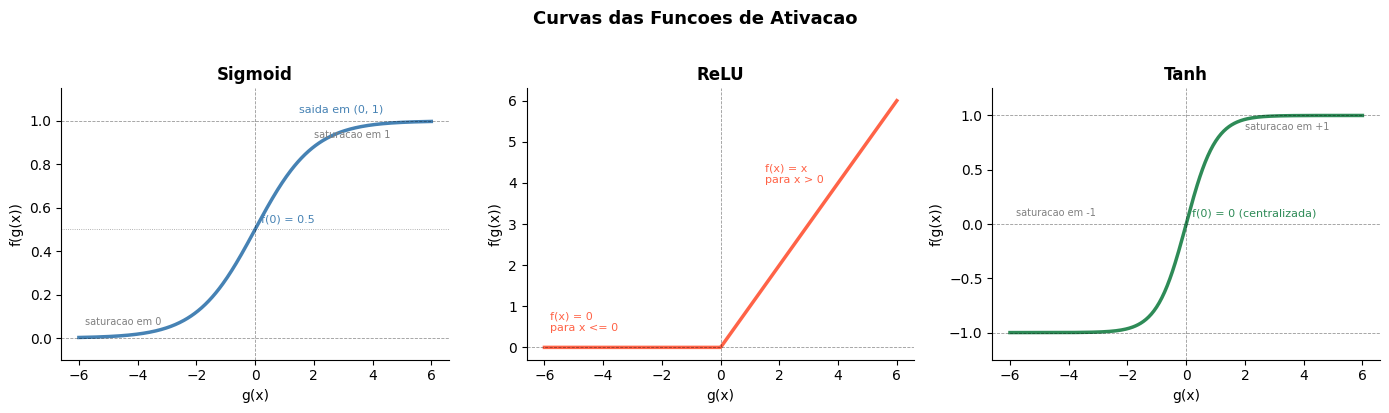

In [12]:
# ------------------------------------------------------------
# Comparacao visual: curvas das tres funcoes de ativacao.
#
# Avalia cada funcao para x no intervalo [-6, +6] e plota
# os tres graficos lado a lado.
# ------------------------------------------------------------

x_range = torch.linspace(-6, 6, 400)

# Calcula a saida de cada funcao para todo o intervalo
# detach() desconecta do grafo de gradiente (desnecessario para plotagem)
y_sigmoid = nn.Sigmoid()(x_range).detach().numpy()
y_relu    = nn.ReLU()(x_range).detach().numpy()
y_tanh    = nn.Tanh()(x_range).detach().numpy()
x_np      = x_range.numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Sigmoid ---
axes[0].plot(x_np, y_sigmoid, color='steelblue', linewidth=2.5)
axes[0].axhline(0,   color='k', linewidth=0.6, linestyle='--', alpha=0.4)
axes[0].axhline(0.5, color='k', linewidth=0.6, linestyle=':',  alpha=0.4)
axes[0].axhline(1,   color='k', linewidth=0.6, linestyle='--', alpha=0.4)
axes[0].axvline(0,   color='k', linewidth=0.6, linestyle='--', alpha=0.4)
axes[0].set_title('Sigmoid', fontweight='bold')
axes[0].set_xlabel('g(x)')
axes[0].set_ylabel('f(g(x))')
axes[0].set_ylim(-0.1, 1.15)
axes[0].text( 1.5, 1.04, 'saida em (0, 1)',  fontsize=8, color='steelblue')
axes[0].text( 0.2, 0.53, 'f(0) = 0.5',       fontsize=8, color='steelblue')
axes[0].text(-5.8, 0.06, 'saturacao em 0',   fontsize=7, color='gray')
axes[0].text( 2.0, 0.92, 'saturacao em 1',   fontsize=7, color='gray')

# --- ReLU ---
axes[1].plot(x_np, y_relu, color='tomato', linewidth=2.5)
axes[1].axhline(0, color='k', linewidth=0.6, linestyle='--', alpha=0.4)
axes[1].axvline(0, color='k', linewidth=0.6, linestyle='--', alpha=0.4)
axes[1].set_title('ReLU', fontweight='bold')
axes[1].set_xlabel('g(x)')
axes[1].set_ylabel('f(g(x))')
axes[1].text(-5.8, 0.4, 'f(x) = 0\npara x <= 0', fontsize=8, color='tomato')
axes[1].text( 1.5, 4.0, 'f(x) = x\npara x > 0',  fontsize=8, color='tomato')

# --- Tanh ---
axes[2].plot(x_np, y_tanh, color='seagreen', linewidth=2.5)
axes[2].axhline( 0, color='k', linewidth=0.6, linestyle='--', alpha=0.4)
axes[2].axhline( 1, color='k', linewidth=0.6, linestyle='--', alpha=0.4)
axes[2].axhline(-1, color='k', linewidth=0.6, linestyle='--', alpha=0.4)
axes[2].axvline( 0, color='k', linewidth=0.6, linestyle='--', alpha=0.4)
axes[2].set_title('Tanh', fontweight='bold')
axes[2].set_xlabel('g(x)')
axes[2].set_ylabel('f(g(x))')
axes[2].set_ylim(-1.25, 1.25)
axes[2].text( 0.2, 0.07, 'f(0) = 0 (centralizada)',  fontsize=8, color='seagreen')
axes[2].text(-5.8, 0.07, 'saturacao em -1',           fontsize=7, color='gray')
axes[2].text( 2.0, 0.87, 'saturacao em +1',           fontsize=7, color='gray')

plt.suptitle('Curvas das Funcoes de Ativacao', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Secao 7 — Tabela Consolidada e Analise dos Resultados

Reunimos todos os resultados em uma unica tabela para comparar  
as tres funcoes sobre os mesmos quatro pontos.

In [13]:
# ------------------------------------------------------------
# Tabela consolidada: as tres funcoes x os quatro pontos.
#
# Para cada ponto calcula g(x), classificacao por limiar e
# a saida de Sigmoid, ReLU e Tanh lado a lado.
# ------------------------------------------------------------

sep = '=' * 92
print(sep)
print('TABELA CONSOLIDADA — Saida de cada funcao de ativacao para os quatro pontos de analise')
print(sep)
print(f'  {"Ponto":>6} | {"g(x)":>8} | {"Limiar":>7} | '
      f'{"Sigmoid":>9} | {"ReLU":>9} | {"Tanh":>9} | {"Real":>5}')
print('  ' + '-' * 76)

for idx in INDICES_ANALISE:
    x_t = torch.Tensor(X[idx])

    # Calcula g(x) uma unica vez e aplica as tres funcoes sobre o mesmo tensor
    g_x    = perceptron(x_t)
    limiar = 1 if g_x.item() >= 0 else 0
    sig    = nn.Sigmoid()(g_x).item()
    rel    = nn.ReLU()(g_x).item()
    tan    = nn.Tanh()(g_x).item()

    print(f'  {idx:>6} | {g_x.item():>+8.3f} | {limiar:>7} | '
          f'{sig:>9.4f} | {rel:>9.4f} | {tan:>+9.4f} | {Y[idx]:>5}')

print(sep)
print()
print('Observacoes:')
print()
print('  1. Sigmoid e Tanh sempre produzem saidas em intervalos limitados.')
print('     Sigmoid: (0, 1)   — interpretavel como probabilidade.')
print('     Tanh:    (-1, +1) — centralizada em zero.')
print()
print('  2. ReLU preserva a magnitude original para valores positivos.')
print('     Para valores negativos, retorna exatamente 0 — neuronio silencioso.')
print()
print('  3. A classificacao por Limiar e identica para as tres funcoes.')
print('     O sinal de g(x) nao muda com a ativacao; apenas a escala e o intervalo mudam.')
print()
print('  4. A Tanh retorna valores negativos para g(x) < 0.')
print('     Esse sinal direcional e informativo para o Backpropagation.')
print()
print('  5. Para classificacao binaria na camada de saida, a Sigmoid e a escolha')
print('     mais adequada: sua saida e interpretavel como probabilidade estimada da classe 1.')

TABELA CONSOLIDADA — Saida de cada funcao de ativacao para os quatro pontos de analise
   Ponto |     g(x) |  Limiar |   Sigmoid |      ReLU |      Tanh |  Real
  ----------------------------------------------------------------------------
      17 |  -18.033 |       0 |    0.0000 |    0.0000 |   -1.0000 |     0
      21 |   -1.536 |       0 |    0.1772 |    0.0000 |   -0.9114 |     0
      43 |   -1.476 |       0 |    0.1860 |    0.0000 |   -0.9008 |     0
      66 |  +16.483 |       1 |    1.0000 |   16.4828 |   +1.0000 |     1

Observacoes:

  1. Sigmoid e Tanh sempre produzem saidas em intervalos limitados.
     Sigmoid: (0, 1)   — interpretavel como probabilidade.
     Tanh:    (-1, +1) — centralizada em zero.

  2. ReLU preserva a magnitude original para valores positivos.
     Para valores negativos, retorna exatamente 0 — neuronio silencioso.

  3. A classificacao por Limiar e identica para as tres funcoes.
     O sinal de g(x) nao muda com a ativacao; apenas a escala e o inter

---
## Secao 8 — Exercicio: Escolha e Justificativa

**Enunciado:**

Considerando o problema de classificacao binaria apresentado nesta atividade,  
implemente o Perceptron com a **funcao de ativacao de sua escolha**  
e justifique essa escolha de forma fundamentada.

Sua resposta deve contemplar os seguintes pontos:

1. Qual funcao de ativacao voce escolheu?
2. Qual e o intervalo de saida dessa funcao?
3. Como a saida sera interpretada neste problema especifico?
4. Por que essa funcao e mais adequada que as outras duas para este caso?

---

> **Orientacao:**  
> Este e um problema de **classificacao binaria** com um Perceptron de saida unica.  
> Pense em qual funcao torna a saida diretamente interpretavel para o usuario final,  
> que precisa decidir entre as duas classes.

In [14]:
# ============================================================
# EXERCICIO — complete a implementacao abaixo
# ============================================================

# Passo 1: defina a funcao de ativacao da sua escolha.
#
# Opcoes disponiveis:
#   activation_escolhida = nn.Sigmoid()
#   activation_escolhida = nn.ReLU()
#   activation_escolhida = nn.Tanh()
#
# Substitua None pela sua escolha:

activation_escolhida = None


# Passo 2: apos definir activation_escolhida, remova o '#'
# das linhas abaixo para executar a analise e visualizacao.

# nome = type(activation_escolhida).__name__
#
# fig, ax = plt.subplots(figsize=(8, 6))
# resultados_ex = analisar_ativacao(activation_escolhida, nome, ax=ax)
# plt.tight_layout()
# plt.show()
#
# print(f'Funcao escolhida: {nome}')
# print(f'  {"Ponto":>6} | {"g(x)":>8} | {"Limiar":>7} | {"Ativada":>9} | {"Real":>5}')
# print('  ' + '-' * 50)
# for r in resultados_ex:
#     print(f'  {r["idx"]:>6} | {r["g_x"]:>+8.3f} | {r["limiar"]:>7} | '
#           f'{r["ativada"]:>+9.4f} | {r["real"]:>5}')

### Justificativa

**Funcao escolhida:**  
*(escreva aqui)*

**Intervalo de saida:**  
*(escreva aqui)*

**Interpretacao da saida neste problema:**  
*(escreva aqui)*

**Por que esta funcao e mais adequada que as outras duas:**  
*(escreva aqui sua argumentacao)*

---

### Referencias

- PyTorch — Modulo `torch.nn`: https://pytorch.org/docs/stable/nn.html  
- McCulloch, W.S.; Pitts, W. (1943). A logical calculus of the ideas immanent in nervous activity. *Bulletin of Mathematical Biophysics*, 5, 115-133.  
- Rosenblatt, F. (1957). *The Perceptron: A Perceiving and Recognizing Automaton*. Cornell Aeronautical Laboratory.  
- Goodfellow, I.; Bengio, Y.; Courville, A. (2016). *Deep Learning*. MIT Press. Cap. 6.